# Coarse Full Waveform Inversion

1. https://www.kaggle.com/competitions/waveform-inversion/code
2. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial/notebook
3. https://arxiv.org/abs/2111.02926

## Imports

In [1]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
from util import get_torch_device_backend
from acoustic_forward_solver import acoustic_forward_solver, FWIPARAMETERS
from gauss_newton_solver import fwi_gn_solver
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import time 
import pyKoLesky.cholesky
import qmcpy as qp
import fastgps
import warnings

## Torch Setup

In [2]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(17)
DEVICE,TORCH_BACKEND = get_torch_device_backend(deviceidx=7)
print("DEVICE = %s"%str(DEVICE))
print("TORCH_BACKEND = %s"%str(TORCH_BACKEND.__name__))
EPS = torch.finfo(torch.get_default_dtype()).eps
EPS

DEVICE = cuda:7
TORCH_BACKEND = torch.cuda


2.220446049250313e-16

## Boilderplate

In [3]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi.ipynb")

In [4]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

In [5]:
def compute_l2errors(x, xhat):
    x = x.flatten(start_dim=1)
    xhat = xhat.flatten(start_dim=1) 
    diff = x-xhat
    xnorm = torch.linalg.norm(x,dim=1)
    diffnorm = torch.linalg.norm(diff,dim=1) 
    l2rerror = diffnorm/xnorm 
    return l2rerror

In [6]:
class Predictor:
    def __init__(self, pred, outputs_cls):
        self.pred = pred 
        self.outputs_cls = outputs_cls
    def forward_eval(self, xtf):
        with torch.no_grad(), torch.inference_mode(), torch.cuda.device(DEVICE):
            outputstf = self.pred(xtf)#.detach()
        y = self.outputs_cls.backwards(outputstf) 
        return y

## Load Dataset

In [7]:
pname = "RES5"
vtype = "Style_B"
tag = "NEWTRY_RELAX_1e+01"
custom_rkhs_v = False
custom_rkhs_w = False
outdir = './data/%s/%s'%(pname,vtype)
assert os.path.isdir(outdir)
p = FWIPARAMETERS[pname]
for _key,_val in p.items():
    print("p['%s'] = %s"%(_key,_val))
print()
_data_split = torch.load(outdir+"/split_train_val.pt",weights_only=True)
_data_nk = torch.load(outdir+"/NK.%s.RKHS_v_%s.RKHS_w_%s.pt"%(tag,"custom" if custom_rkhs_v else "eye","custom" if custom_rkhs_w else "eye"),weights_only=True)
data = {**_data_split,**_data_nk}
for _key,_val in data.items():
    print("data['%s'].shape = %s"%(_key,str(tuple(_val.shape))))
print()
Thetainv_v = torch.load(outdir+"/RKHS_v_%s.pt"%("custom" if custom_rkhs_v else "eye"),weights_only=True)["Thetainv"]
Thetainv_w = torch.load(outdir+"/RKHS_w_%s.pt"%("custom" if custom_rkhs_w else "eye"),weights_only=True)["Thetainv"]
print("Thetainv_v.shape = %s"%str(tuple(Thetainv_v.shape)))
print("Thetainv_w.shape = %s"%str(tuple(Thetainv_w.shape)))

p['name'] = RES5
p['nx'] = 5
p['dx'] = 10
p['nbc'] = 8
p['nt'] = 72
p['dt'] = 0.001
p['freq'] = 35
p['coord_sx'] = [0.7142857142857143, 12.5, 25.0, 37.857142857142854, 50.0]
p['coord_sz'] = [0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143]

data['velocity'].shape = (1000, 5, 5)
data['wavefield'].shape = (1000, 5, 71, 5)
data['velocity_train'].shape = (800, 5, 5)
data['velocity_val'].shape = (200, 5, 5)
data['wavefield_train'].shape = (800, 5, 71, 5)
data['wavefield_val'].shape = (200, 5, 71, 5)
data['tidxs'].shape = (800,)
data['vidxs'].shape = (200,)
data['vs'].shape = (1000, 401, 5, 5)
data['rmses'].shape = (1000, 401)
data['times'].shape = (401,)
data['relaxations'].shape = (1000, 401)
data['lrs'].shape = (1000, 401)
data['updated'].shape = (1000, 400)
data['Linvs'].shape = (1000, 400, 25, 25)
data['cond_nums'].shape = (1000, 400)
data['l2rerrors'].shape = (1000, 401)
data['v_true'].shape = (1000, 5, 5)
data['w_true'].shape = (1000,

In [8]:
R,Ns,Nt,Nx = data["wavefield"].shape
lti0,lti1 = torch.tril_indices(Nx**2,Nx**2)
eyeNx2 = torch.eye(Nx**2,device=DEVICE)
Nx2r = torch.arange(Nx*Nx)

## Explore Dataset

### Tables

In [9]:
print("L2 relative errors")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["l2rerrors"]).describe().T.iloc[::5])

L2 relative errors


,count,mean,std,min,25%,50%,75%,max
0,1000.0,8.128776e-02,1.182117e-02,5.567941e-02,7.327917e-02,7.972950e-02,8.771024e-02,1.509918e-01
5,1000.0,1.389973e-02,2.365540e-02,9.897725e-06,2.173064e-03,5.831143e-03,1.479949e-02,2.415914e-01
10,1000.0,2.337724e-04,3.902967e-03,2.005989e-14,8.625938e-08,1.531431e-06,1.323350e-05,1.196921e-01
15,1000.0,2.532616e-06,7.778869e-05,2.991352e-15,1.497013e-14,5.604540e-14,4.701629e-11,2.459364e-03
20,1000.0,1.487125e-10,3.718370e-09,2.111210e-15,8.909199e-15,1.313144e-14,2.143028e-14,1.140339e-07
25,1000.0,6.002826e-14,1.240880e-12,1.675879e-15,8.517418e-15,1.247579e-14,1.931092e-14,3.899680e-11
30,1000.0,1.522555e-14,1.019780e-14,1.675879e-15,8.431738e-15,1.240917e-14,1.895741e-14,7.595067e-14
35,1000.0,1.521270e-14,1.013745e-14,1.675879e-15,8.431738e-15,1.240917e-14,1.895741e-14,7.595067e-14
40,1000.0,1.521270e-14,1.013745e-14,1.675879e-15,8.431738e-15,1.240917e-14,1.895741e-14,7.595067e-14
45,1000.0,1.521270e-14,1.013745e-14,1.675879e-15,8.431738e-15,1.240917e-14,1.895741e-14,7.595067e-14


In [10]:
print("Relaxations")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["relaxations"]).describe().T.iloc[::5])

Relaxations


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01
5,1000.0,4.347812e+00,4.020029e+00,3.125000e-01,2.500000e+00,2.500000e+00,5.000000e+00,4.000000e+01
10,1000.0,5.735449e-01,7.907018e-01,9.765625e-03,7.812500e-02,3.125000e-01,6.250000e-01,1.000000e+01
15,1000.0,1.226727e-01,3.336466e-01,6.103516e-04,9.765625e-03,1.953125e-02,3.906250e-02,2.500000e+00
20,1000.0,1.701300e-01,5.070497e-01,7.629395e-05,4.882812e-03,1.953125e-02,7.812500e-02,1.000000e+01
25,1000.0,3.828466e+00,1.479752e+01,1.525879e-04,7.812500e-02,3.125000e-01,2.500000e+00,3.200000e+02
30,1000.0,1.218012e+02,4.736507e+02,2.441406e-03,2.500000e+00,1.000000e+01,4.000000e+01,1.024000e+04
35,1000.0,3.897573e+03,1.515684e+04,7.812500e-02,8.000000e+01,3.200000e+02,1.280000e+03,3.276800e+05
40,1000.0,1.247223e+05,4.850189e+05,2.500000e+00,2.560000e+03,1.024000e+04,4.096000e+04,1.048576e+07
45,1000.0,3.991115e+06,1.552060e+07,8.000000e+01,8.192000e+04,3.276800e+05,1.310720e+06,3.355443e+08


In [11]:
print("Learning rates")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["lrs"]).describe().T.iloc[::5])

Learning rates


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
5,1000.0,1.427000e+00,5.009211e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
10,1000.0,1.174000e+00,3.792992e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
15,1000.0,8.550625e-01,3.252903e-01,6.250000e-02,5.000000e-01,1.000000e+00,1.000000e+00,2.000000e+00
20,1000.0,2.610293e-01,3.661191e-01,1.953125e-03,3.125000e-02,1.250000e-01,2.500000e-01,2.000000e+00
25,1000.0,4.178949e-02,1.373845e-01,6.103516e-05,9.765625e-04,3.906250e-03,1.562500e-02,1.000000e+00
30,1000.0,4.387953e-03,3.831891e-02,1.907349e-06,3.051758e-05,1.220703e-04,4.882812e-04,1.000000e+00
35,1000.0,1.644673e-04,1.545295e-03,5.960464e-08,9.536743e-07,3.814697e-06,1.525879e-05,3.125000e-02
40,1000.0,5.139602e-06,4.829046e-05,1.862645e-09,2.980232e-08,1.192093e-07,4.768372e-07,9.765625e-04
45,1000.0,1.606126e-07,1.509077e-06,5.820766e-11,9.313226e-10,3.725290e-09,1.490116e-08,3.051758e-05


### Plots

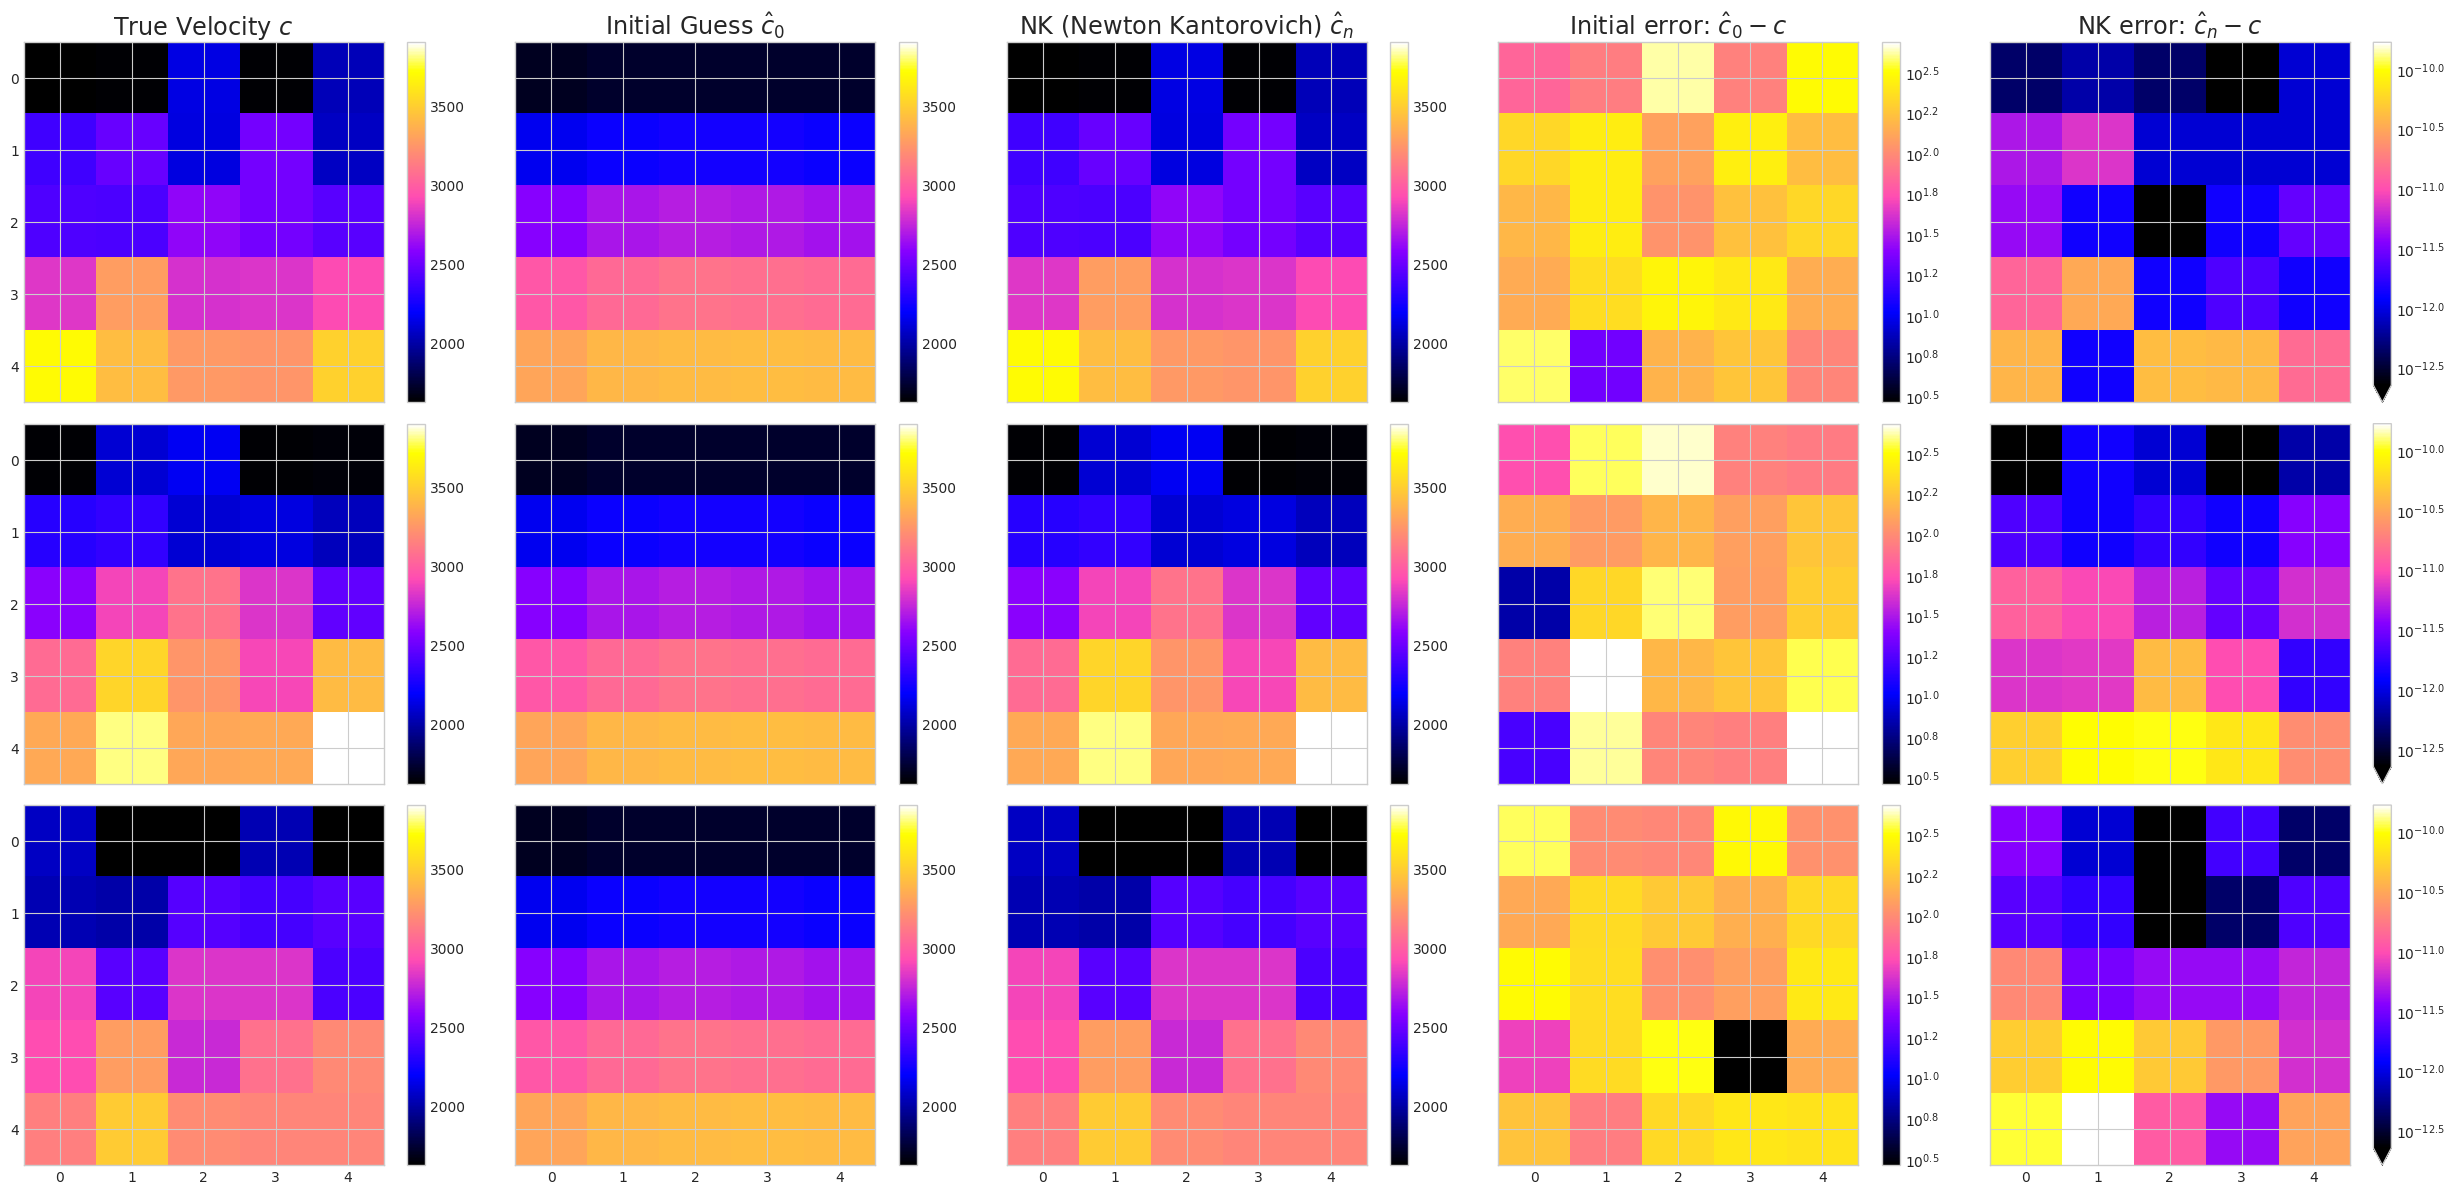

In [12]:
def plot_nk_velocities(v_true, v0, vfinal, contours=False):
    initial_error_log10 = torch.log10(torch.abs(v_true-v0))
    final_error_log10 = torch.log10(torch.abs(v_true-vfinal))
    final_error_log10[final_error_log10==-torch.inf] = final_error_log10[final_error_log10.isfinite()].min()
    _initial_error_log10_amin = initial_error_log10.min()
    _initial_error_log10_amax = initial_error_log10.max()
    _final_error_log10_amin = final_error_log10.min()
    _final_error_log10_amax = final_error_log10.max()
    _cbmin = torch.min(v_true.min(),v0.min())
    _cbmax = torch.max(v_true.max(),v0.max())
    _plot_data = [
        (v_true,r"True Velocity $c$",_cbmin,_cbmax,False,None),
        (v0,r"Initial Guess $\hat{c}_0$",_cbmin,_cbmax,False,None),
        (vfinal,r"NK (Newton Kantorovich) $\hat{c}_n$",_cbmin,_cbmax,False,None),
        (initial_error_log10,r"Initial error: $\hat{c}_0-c$",_initial_error_log10_amin,_initial_error_log10_amax,True,None),
        (final_error_log10,r"NK error: $\hat{c}_n-c$",_final_error_log10_amin,_final_error_log10_amax,True,"min"),
        ]
    nrows = _plot_data[0][0].size(0)
    ncols = len(_plot_data)
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,4*nrows),sharex=True,sharey=True)
    ax = ax.reshape((nrows,ncols))
    for j,(_v,name,_vmin,_vmax,log10ed,extend) in enumerate(_plot_data):
        for i in range(nrows):
            cax = ax[i,j].imshow(_v[i].cpu(),cmap="gnuplot2",vmin=_vmin if _vmin is not None else None,vmax=_vmax if _vmax is not None else None)
            cbar = fig.colorbar(cax,extend=extend)
            if log10ed:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore",UserWarning)
                    cbar.ax.set_yticklabels([r"$10^{%.1f}$"%(int(_tick) if _tick%1==0 else _tick) for _tick in cbar.ax.get_yticks()]) 
        ax[0,j].set_title(name,fontsize="xx-large")
    fig.tight_layout()
    return fig,ax 
_R = 3
fig,ax = plot_nk_velocities(data["velocity"][:_R],data["vs"][:_R,0],data["vs"][:_R,-1],contours=True)
fig.savefig(outdir+"/fwi_data.png",dpi=256)

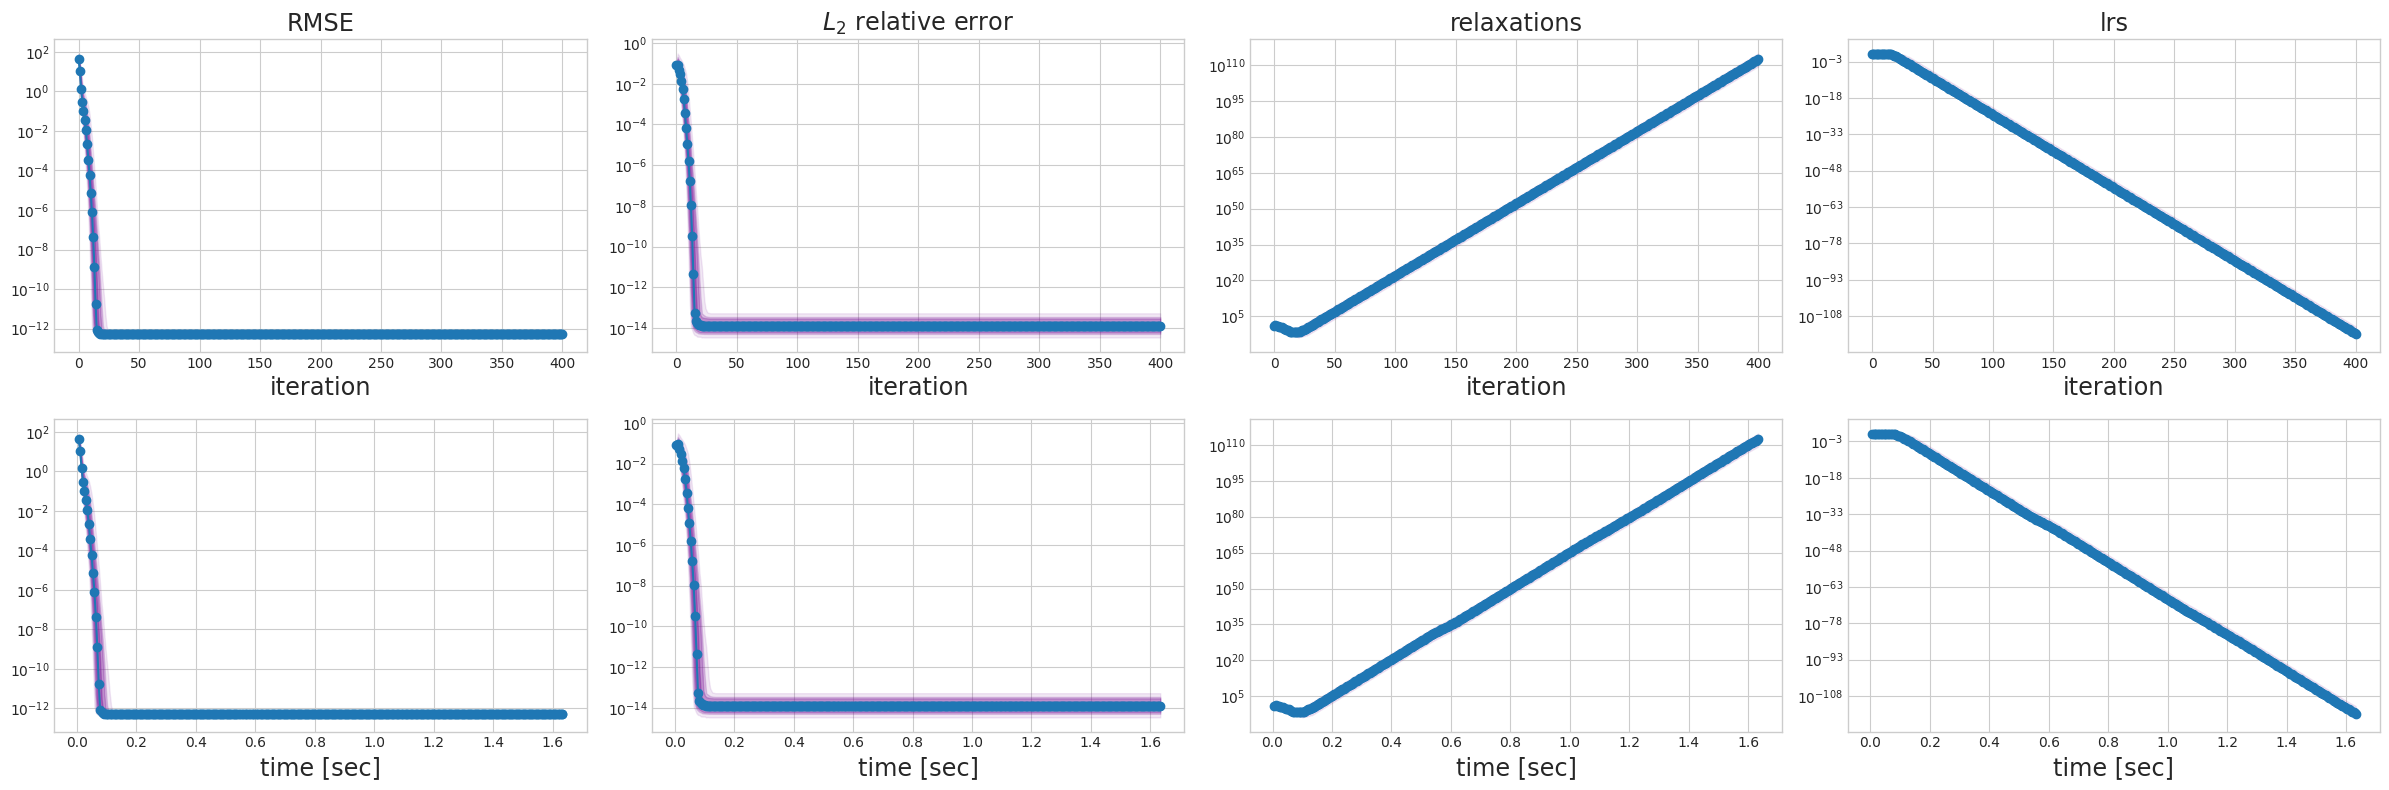

In [13]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmses"],None)],
            [(None,data["l2rerrors"],None)],
            [(None,data["relaxations"],None)],
            [(None,data["lrs"],None)],

        ],
        [
            [(data["times"].cumsum(0),data["rmses"],None)],
            [(data["times"].cumsum(0),data["l2rerrors"],None)],
            [(data["times"].cumsum(0),data["relaxations"],None)],
            [(data["times"].cumsum(0),data["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True,
    fsx=4,fsy=6,
    legends=False)
fig.tight_layout()
fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

## Initial Guess Model

### Input Data

In [14]:
class InputDataTFIG:
    def __init__(self, w, tidxs, vidxs, normalize=False):
        self.normalize = normalize
        assert w.device==tidxs.device==vidxs.device
        self.w_t = w[tidxs]
        self.w_v = w[vidxs]
        if self.normalize:
            w_t_mean = self.w_t.mean(0)
            w_t_std = self.w_t.std(0)
            w_t_std[w_t_std==0] = 1
            self.w_t = (self.w_t-w_t_mean)/w_t_std
            self.w_v = (self.w_v-w_t_mean)/w_t_std
        self.w_t = self.w_t.flatten(start_dim=1) 
        self.w_v = self.w_v.flatten(start_dim=1) 
inputs_ig_cls = InputDataTFIG(
    data["wavefield"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    normalize = True,
)
print("inputs_ig_cls.w_t.shape = %s"%str(tuple(inputs_ig_cls.w_t.shape)))
print("inputs_ig_cls.w_v.shape = %s"%str(tuple(inputs_ig_cls.w_v.shape)))

inputs_ig_cls.w_t.shape = (800, 1775)
inputs_ig_cls.w_v.shape = (200, 1775)


### Output Data

In [15]:
class OutputDataTFIG:
    def __init__(self, v, tidxs, vidxs, normalize=False, log=False):
        self.normalize = normalize
        self.log = log
        assert v.device==tidxs.device==vidxs.device
        self.nonbatch_shape = list(v.shape[1:])
        self.v_t = v[tidxs]
        self.v_v = v[vidxs]
        if self.log:
            self.v_t = torch.log(self.v_t)
            self.v_v = torch.log(self.v_v)
        if self.normalize:
            self.v_t_mean = self.v_t.mean(0)
            self.v_t_std = self.v_t.std(0).clone()
            self.v_t_std[self.v_t_std==0] = 1
            self.v_t = (self.v_t-self.v_t_mean)/self.v_t_std
            self.v_v = (self.v_v-self.v_t_mean)/self.v_t_std
        self.v_t = self.v_t.flatten(start_dim=1)
        self.v_v = self.v_v.flatten(start_dim=1)
    def backwards(self, outputs):
        outputs = outputs.reshape([-1]+list(self.nonbatch_shape))
        if self.normalize:
            outputs = outputs*self.v_t_std+self.v_t_mean
        if self.log:
            outputs = torch.exp(outputs)
        return outputs
outputs_ig_cls = OutputDataTFIG(
    data["velocity"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    normalize = True, 
    log = True,
)
print("outputs_ig_cls.v_t.shape = %s"%str(tuple(outputs_ig_cls.v_t.shape)))
print("outputs_ig_cls.v_v.shape = %s"%str(tuple(outputs_ig_cls.v_v.shape)))

outputs_ig_cls.v_t.shape = (800, 25)
outputs_ig_cls.v_v.shape = (200, 25)


### Model Prep

In [16]:
outdir_igmodels = outdir+"/MODELS_IG"
if not os.path.isdir(outdir_igmodels): os.mkdir(outdir_igmodels)

### GP

In [17]:
import gc; gc.collect()
torch.cuda.empty_cache()
sgp_ig = fastgps.StandardGP(
    qp.KernelMatern52(
        d = Ns*Nt*Nx,
        # scale = 1, 
        #shape_scale = [1],
        shape_scale = [Nx*Nx,1],
        lengthscales=Ns*Nt*Nx,
        # shape_lengthscales=[1],
        shape_lengthscales=[Ns*Nt*Nx],
        torchify = True,
        device = DEVICE, 
        compile_call = True),
    {"x": inputs_ig_cls.w_t,  "y": outputs_ig_cls.v_t.T},
    noise=1e-8,
    #shape_noise = [1],
    shape_noise=[Nx*Nx,1],
    requires_grad_noise=True,
)
for _pname,_pval in sgp_ig.named_parameters():
    print("%s.shape = %s"%(_pname,str(tuple(_pval.shape))))
print()
fit_data_sgp_ig = sgp_ig.fit(
    loss_metric="CV",
    cv_weights=1/torch.linalg.norm(data["velocity_train"],dim=(1,2)).to(DEVICE),
    iterations=100,
    verbose=10,
    store_hists=True,
    stop_crit_wait_iterations=np.inf,
    stop_crit_improvement_threshold=1e-1,
    lr = 1e-3
    #optimizer = torch.optim.Rprop(sgp_ig.parameters(),lr=1e-1,etas=(1/1000,1001/1000),step_sizes=(0,5))
    )

raw_noise.shape = (25, 1)
kernel.raw_factor.shape = (1, 1)
kernel.raw_diag.shape = (1,)
kernel.base_kernel.raw_scale.shape = (25, 1)
kernel.base_kernel.raw_lengthscales.shape = (1775,)

     iter of 1.0e+02 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 1.14e-01   | 1.14e-01  
            1.00e+01 | 1.12e-01   | 1.12e-01  
            2.00e+01 | 1.03e-01   | 1.03e-01  
            3.00e+01 | 7.92e-02   | 7.92e-02  
            4.00e+01 | 6.96e-02   | 6.96e-02  
            5.00e+01 | 6.64e-02   | 6.64e-02  
            6.00e+01 | 6.47e-02   | 6.47e-02  
            7.00e+01 | 6.37e-02   | 6.39e-02  
            8.00e+01 | 6.33e-02   | 6.33e-02  
            9.00e+01 | 6.33e-02   | 6.33e-02  
            1.00e+02 | 6.28e-02   | 6.28e-02  


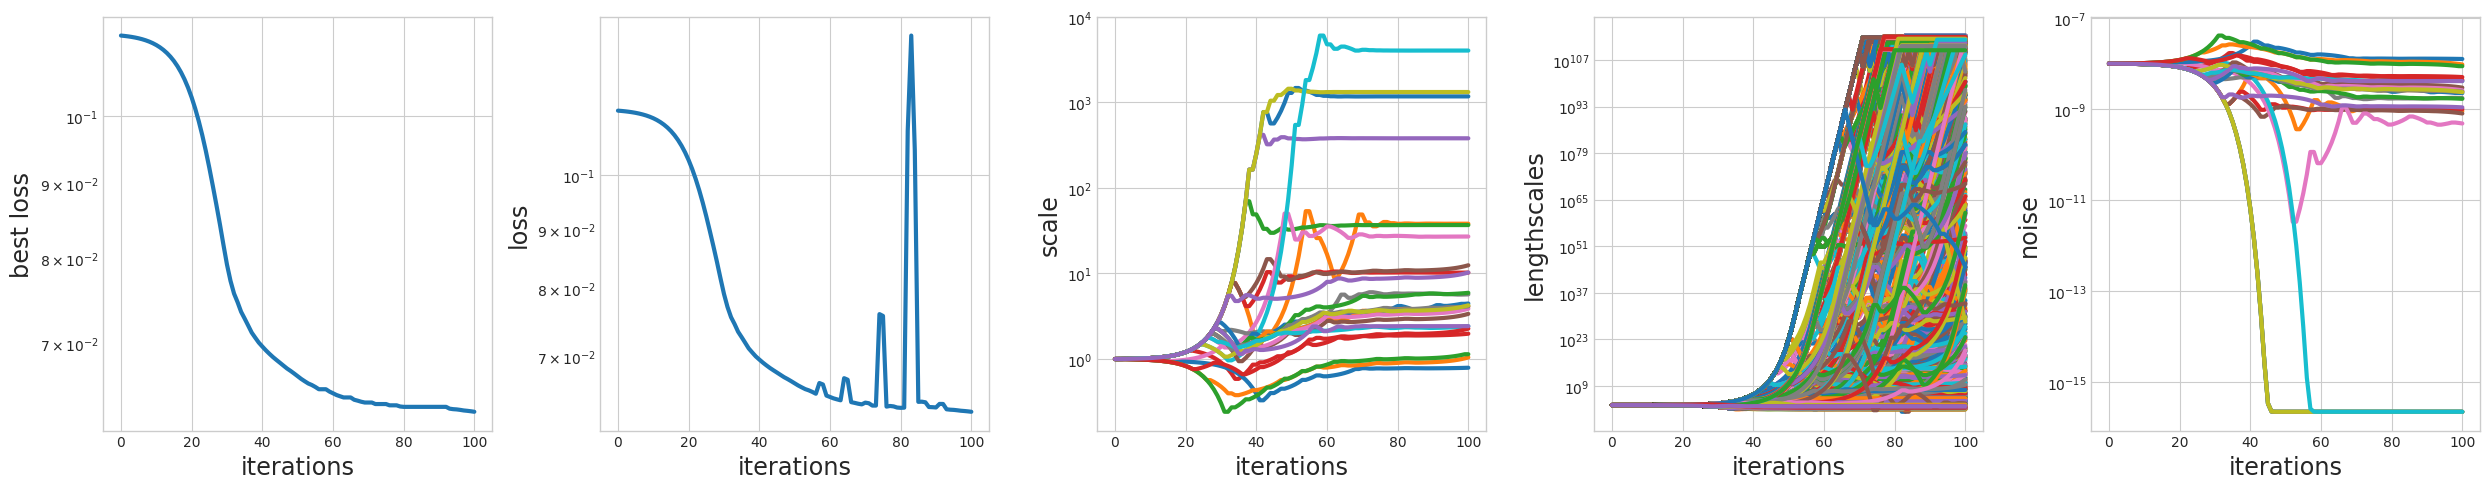

In [18]:
fastgps.plot_fastgps_fit_data(fit_data_sgp_ig,["best_loss","loss","scale","lengthscales","noise"]);

In [19]:
gp_ig_predictor_cls = Predictor(lambda w: sgp_ig.post_mean(w).T, outputs_ig_cls)
vhat_ig_gp = gp_ig_predictor_cls.forward_eval(inputs_ig_cls.w_v)
print("l2 relative error: %.2e"%(compute_l2errors(data["velocity_val"].to(DEVICE),vhat_ig_gp).mean()))

l2 relative error: 2.22e-02


## CHONKNORIS Model

### Input Data

In [20]:
class InputDataTF:
    def __init__(self, relaxation, v, w, tidxs, vidxs, updated, Midxs, normalize=False, log_relaxation=False, log_v=False):
        M = v.size(1) # total number of iterations
        assert (Midxs<(M-1)).all(), "Midxs must be less than M-1=%d"%(M-1)
        self.normalize = normalize
        self.log_relaxation = log_relaxation
        self.log_v = log_v
        assert relaxation.device==v.device==w.device==tidxs.device==vidxs.device==Midxs.device==updated.device
        _updated = updated[:,Midxs]
        updated_t = _updated[tidxs]
        updated_v = _updated[vidxs]
        _vs = v[:,Midxs]
        vs_t = _vs[tidxs][updated_t]
        vs_v = _vs[vidxs][updated_v]
        _relaxations = relaxation[:,Midxs+1]
        relaxations_t = _relaxations[tidxs][updated_t]
        relaxations_v = _relaxations[vidxs][updated_v]
        _wavefield_full = torch.tile(w[:,None,:,:,:],(1,len(Midxs),1,1,1))
        wavefield_full_t = _wavefield_full[tidxs][updated_t]
        wavefield_full_v = _wavefield_full[vidxs][updated_v]
        if self.log_relaxation:
            relaxations_t = torch.log(relaxations_t)
            relaxations_v = torch.log(relaxations_v)
        if self.log_v:
            vs_t = torch.log(vs_t)
            vs_v = torch.log(vs_v)
        self.inputs_t = torch.cat([relaxations_t[:,None],vs_t.flatten(start_dim=1),wavefield_full_t.flatten(start_dim=1)],dim=-1)
        self.inputs_v = torch.cat([relaxations_v[:,None],vs_v.flatten(start_dim=1),wavefield_full_v.flatten(start_dim=1)],dim=-1)
        if self.normalize:
            self.inputs_t_mean = self.inputs_t.mean(0) 
            self.inputs_t_std = self.inputs_t.std(0) 
            self.inputs_t_std[self.inputs_t_std==0] = 1
            self.inputs_t = (self.inputs_t-self.inputs_t_mean)/self.inputs_t_std
            self.inputs_v = (self.inputs_v-self.inputs_t_mean)/self.inputs_t_std
    def forwards(self, relaxation, v, w):
        assert relaxation.ndim==1 and v.ndim>=2 and w.ndim>=2
        assert relaxation.shape[0]==v.shape[0]==w.shape[0]
        if self.log_relaxation:
            relaxation = torch.log(relaxation) 
        if self.log_v:
            v = torch.log(v) 
        inputs = torch.cat([relaxation[...,None],v.flatten(start_dim=1),w.flatten(start_dim=1)],dim=1)
        if self.normalize:
            inputs = (inputs-self.inputs_t_mean)/self.inputs_t_std
        return inputs
Midxs = torch.linspace(1,29,steps=15,dtype=int,device=DEVICE)
# Midxs = torch.linspace(1,19,steps=10,dtype=int,device=DEVICE)
# Midxs = torch.linspace(0,10,steps=9,dtype=int,device=DEVICE)
# Midxs = torch.linspace(0,25,steps=5,dtype=int,device=DEVICE)
print("Midxs = %s"%str(Midxs.cpu().numpy()))
print("len(Midxs) = %d"%len(Midxs))
inputs_cls = InputDataTF(
    data["relaxations"].to(DEVICE),
    data["vs"].to(DEVICE), 
    data["wavefield"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    data["updated"].to(DEVICE),
    Midxs = Midxs,
    normalize = True, 
    log_relaxation = True, 
    log_v = True,
)
print("inputs_cls.inputs_t.shape = %s"%str(tuple(inputs_cls.inputs_t.shape)))
print("inputs_cls.inputs_v.shape = %s"%str(tuple(inputs_cls.inputs_v.shape)))

Midxs = [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]
len(Midxs) = 15
inputs_cls.inputs_t.shape = (7341, 1801)
inputs_cls.inputs_v.shape = (1849, 1801)


### Output Data

In [21]:
class OutputDataTF:
    def __init__(self, L, tidxs, vidxs, updated, Midxs, normalize=False, log_diag=False):
        self.normalize = normalize
        self.log_diag = log_diag 
        assert L.device==tidxs.device==vidxs.device==Midxs.device
        L = L[:,Midxs]
        _updated = updated[:,Midxs].clone()
        updated_t = _updated[tidxs]
        updated_v = _updated[vidxs]
        self.L_t = L[tidxs][updated_t].clone()
        self.L_v = L[vidxs][updated_v]
        L_t = self.L_t.clone()
        L_v = self.L_v.clone()
        if self.log_diag:
            L_t[...,Nx2r,Nx2r] = torch.log(L_t[...,Nx2r,Nx2r])
            L_v[...,Nx2r,Nx2r] = torch.log(L_v[...,Nx2r,Nx2r])
        self.outputs_t = L_t[:,lti0,lti1]
        self.outputs_v = L_v[:,lti0,lti1]
        if self.normalize:
            self.outputs_t_mean = self.outputs_t.mean(0)
            self.outputs_t_std = self.outputs_t.std(0)
            self.outputs_t_std[self.outputs_t_std==0] = 1
            self.outputs_t = (self.outputs_t-self.outputs_t_mean)/self.outputs_t_std
            self.outputs_v = (self.outputs_v-self.outputs_t_mean)/self.outputs_t_std
    def backwards(self, outputs):
        if self.normalize:
            outputs = outputs*self.outputs_t_std+self.outputs_t_mean
        L = torch.zeros(list(outputs.shape[:-1])+[Nx**2,Nx**2],device=outputs.device)
        L[...,lti0,lti1] = outputs
        if self.log_diag:
            L[...,Nx2r,Nx2r] = torch.exp(L[...,Nx2r,Nx2r])
        return L
outputs_cls = OutputDataTF(
    torch.linalg.solve_triangular(data["Linvs"].to(DEVICE),eyeNx2,upper=False),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    data["updated"].to(DEVICE),
    Midxs = Midxs,
    normalize = True, 
    log_diag = True,
)
print("outputs_cls.outputs_t.shape = %s"%str(tuple(outputs_cls.outputs_t.shape)))
print("outputs_cls.outputs_v.shape = %s"%str(tuple(outputs_cls.outputs_v.shape)))

outputs_cls.outputs_t.shape = (7341, 325)
outputs_cls.outputs_v.shape = (1849, 325)


### Model Prep

In [22]:
outdir_chonknoris = outdir+"/MODELS_L"
if not os.path.isdir(outdir_chonknoris): os.mkdir(outdir_chonknoris)

## GPR

In [23]:
import gc
gc.collect()
torch.cuda.empty_cache()
sgp = fastgps.StandardGP(
    qp.KernelSquaredExponential(
        d = 1+Nx*Nx+Ns*Nt*Nx,
        #shape_scale = [Nx*Nx*(1+Nx*Nx)//2,1],
        lengthscales=1+Nx*Nx+Ns*Nt*Nx,
        #shape_lengthscales=[1],
        shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
        torchify = True,
        device = DEVICE,
        compile_call = True,
    ),
    {"x":inputs_cls.inputs_t,"y":outputs_cls.outputs_t.T},
    noise = 1e-8,
    requires_grad_noise=True,
)
for _pname,_pval in sgp.named_parameters():
    print("%s.shape = %s"%(_pname,str(tuple(_pval.shape))))
print()
fit_data_sgp = sgp.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(outputs_cls.L_t,dim=(1,2)),
    #cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 50,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = np.inf,
    #stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

raw_noise.shape = (1,)
kernel.raw_factor.shape = (1, 1)
kernel.raw_diag.shape = (1,)
kernel.base_kernel.raw_scale.shape = (1,)
kernel.base_kernel.raw_lengthscales.shape = (1801,)

     iter of 5.0e+01 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 1.58e+02   | 1.58e+02  
            1.00e+00 | 1.46e+02   | 1.46e+02  
            2.00e+00 | 1.34e+02   | 1.34e+02  
            3.00e+00 | 1.23e+02   | 1.23e+02  
            4.00e+00 | 1.13e+02   | 1.13e+02  
            5.00e+00 | 1.05e+02   | 1.05e+02  
            6.00e+00 | 1.01e+02   | 1.01e+02  
            7.00e+00 | 9.85e+01   | 9.85e+01  
            8.00e+00 | 9.60e+01   | 9.60e+01  
            9.00e+00 | 9.38e+01   | 9.38e+01  
            1.00e+01 | 9.12e+01   | 9.12e+01  
            1.10e+01 | 8.75e+01   | 8.75e+01  
            1.20e+01 | 8.39e+01   | 8.39e+01  
            1.30e+01 | 8.10e+01   | 8.10e+01  
            1.40e+01 | 7.99e+01   | 7.99e+01  
            1.50e+01 

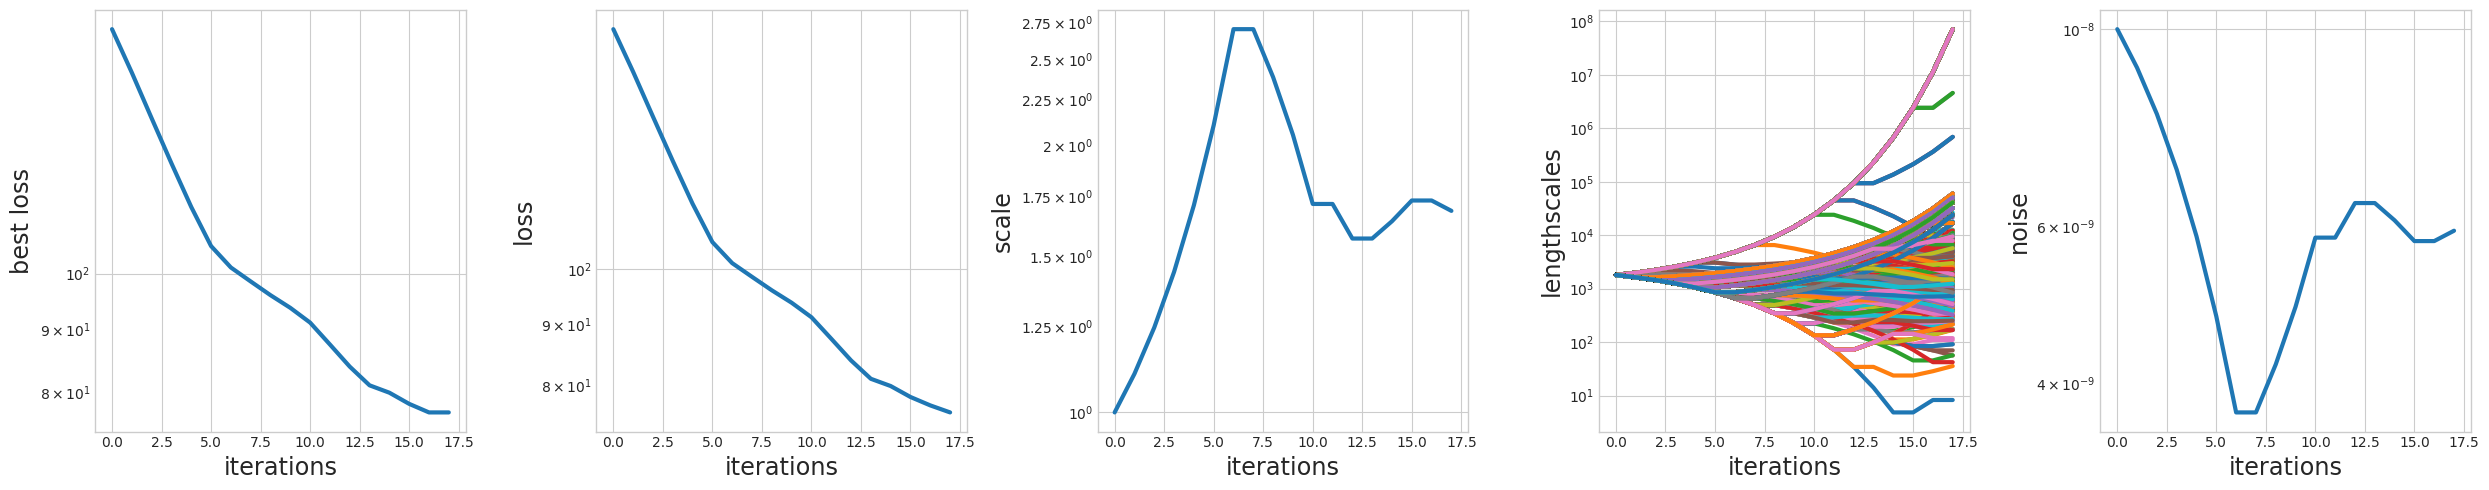

In [24]:
fastgps.plot_fastgps_fit_data(fit_data_sgp,["best_loss","loss","scale","lengthscales","noise"]);

In [25]:
gp_predictor_cls = Predictor(lambda inputs: sgp.post_mean(inputs).T, outputs_cls)
Lhat_gp = gp_predictor_cls.forward_eval(inputs_cls.inputs_v)
print("l2 relative error: %.2e"%(compute_l2errors(outputs_cls.L_v,Lhat_gp).mean()))

l2 relative error: 2.35e-02


## Inference

In [27]:
class InferenceMachine:
    def __init__(self, predictor, inputs_cls):
        self.predictor = predictor 
        self.inputs_cls = inputs_cls
    def predict(self, relaxations, v, w, JtF):
        inputs = self.inputs_cls.forwards(relaxations, v, w)
        Lhat = self.predictor.forward_eval(inputs)
        success = torch.ones(relaxations.size(0),dtype=bool,device=relaxations.device)
        delta_try = torch.cholesky_solve(JtF[success,:,None],Lhat[success],upper=False)[...,0]
        return delta_try,success
R_infer = 25
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
v0 = vhat_ig_gp[:R_infer]
verbose =  5 # 100
num_newton_iter = 40 # 25000
_,data_infer = fwi_gn_solver(p,w,v0,Thetainv_v=Thetainv_v.to(DEVICE),Thetainv_w=Thetainv_w.to(DEVICE),vref=vref,
                             predict=InferenceMachine(gp_predictor_cls, inputs_cls).predict,
                             num_newton_iter=num_newton_iter,
                             relaxation=1e1,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,np.inf),
                             range_lrs = (0,np.inf),
                             print_rmse_flow=False,
                             verbose = verbose
                             )
torch.save(data_infer,outdir+"/CHONKNORIS.GP.SAVE.%s.%s.pt"%(pname,vtype))

    iter of 40     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 1.10e+01  | 4.25e-01     9.31e-01     1.19e+00     3.16e+00     100.0        | 8.73e-03     1.55e-02     2.03e-02     4.76e-02     | 1.00e+01     1.00e+01     1.00e+01     1.00e+01     | 1.00e+

/data2/agsorok/CHONKNORIS/chonknoris/plots.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


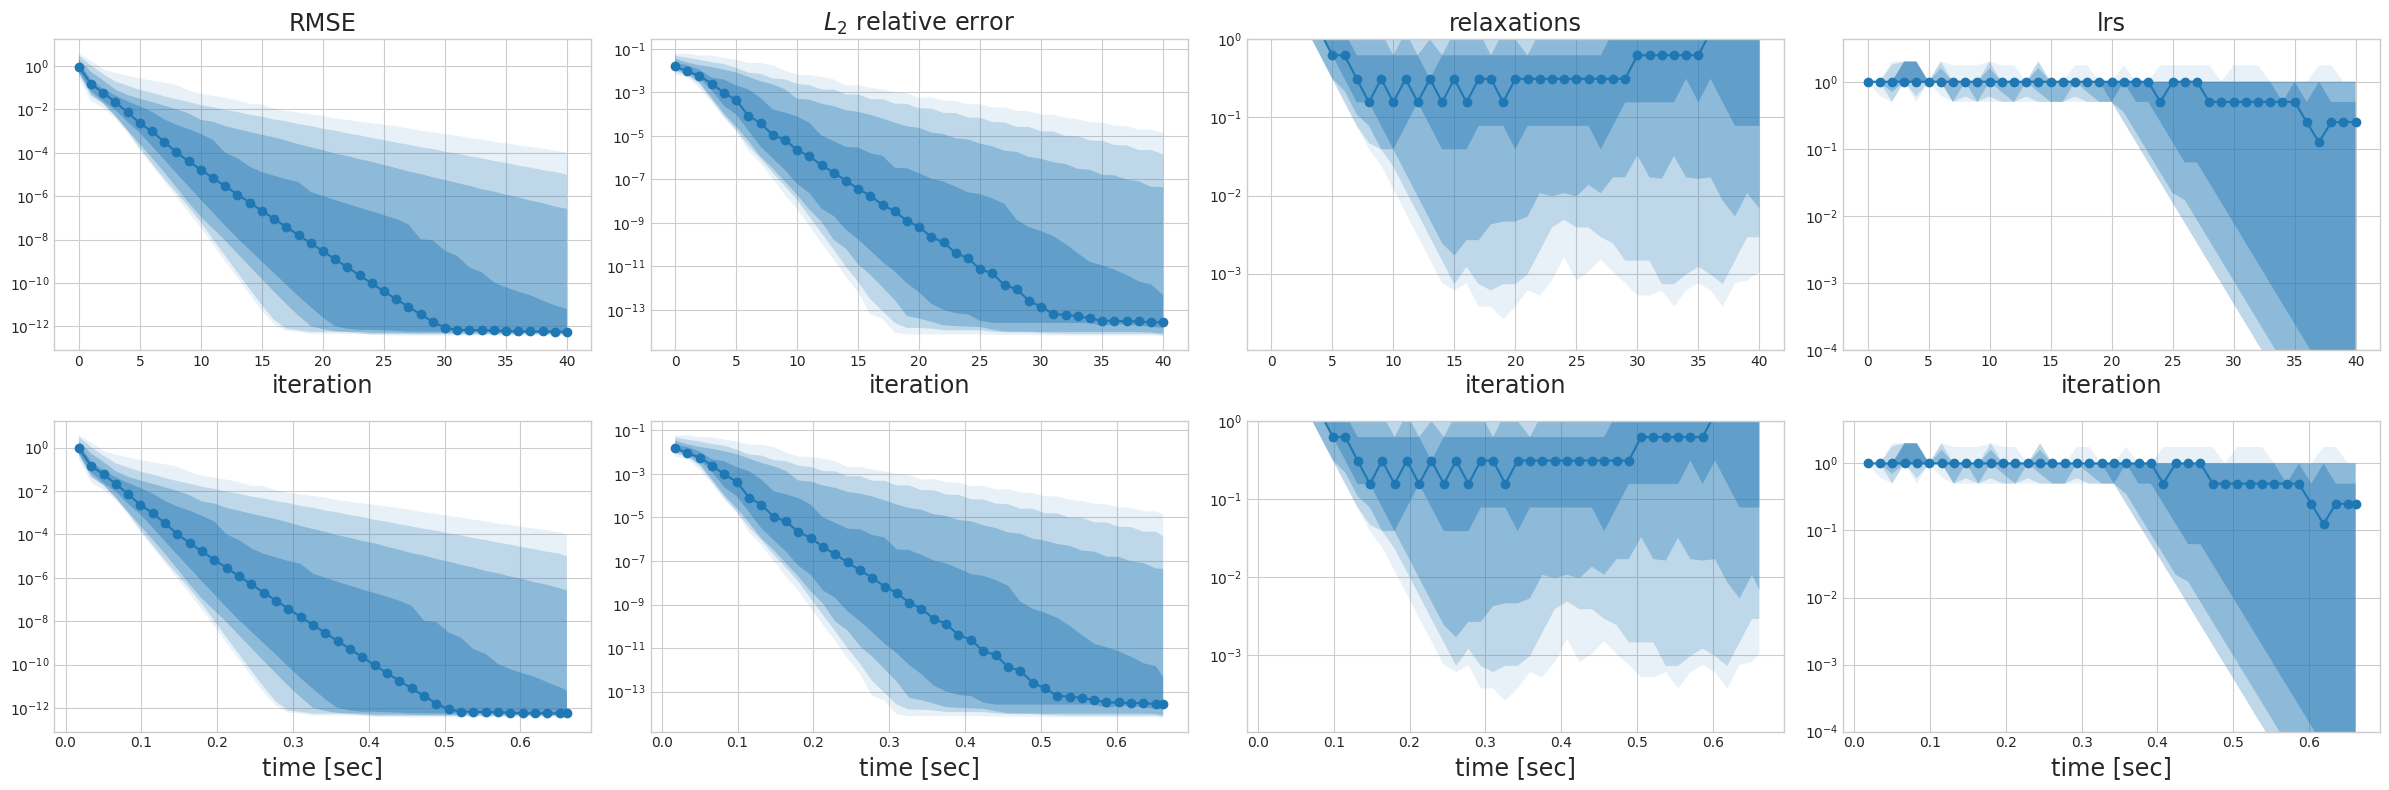

In [28]:
nnif = data_infer["rmses"].size(1) 
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                #(None,data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["rmses"],None)
            ],
            [
                #(None,data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["l2rerrors"],None)],
            [
                #(None,data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["relaxations"],None)],
            [
                #(None,data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["lrs"],None)],

        ],
        [
            [
                #(data["times"][:nnif].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    ylogscale = True,
    # colors = COLORS,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()

tensor([0.0101, 0.0205, 0.0147, 0.0276, 0.0203])
tensor([1.4912e-14, 2.2512e-13, 8.9567e-15, 1.3608e-10, 5.4379e-10])


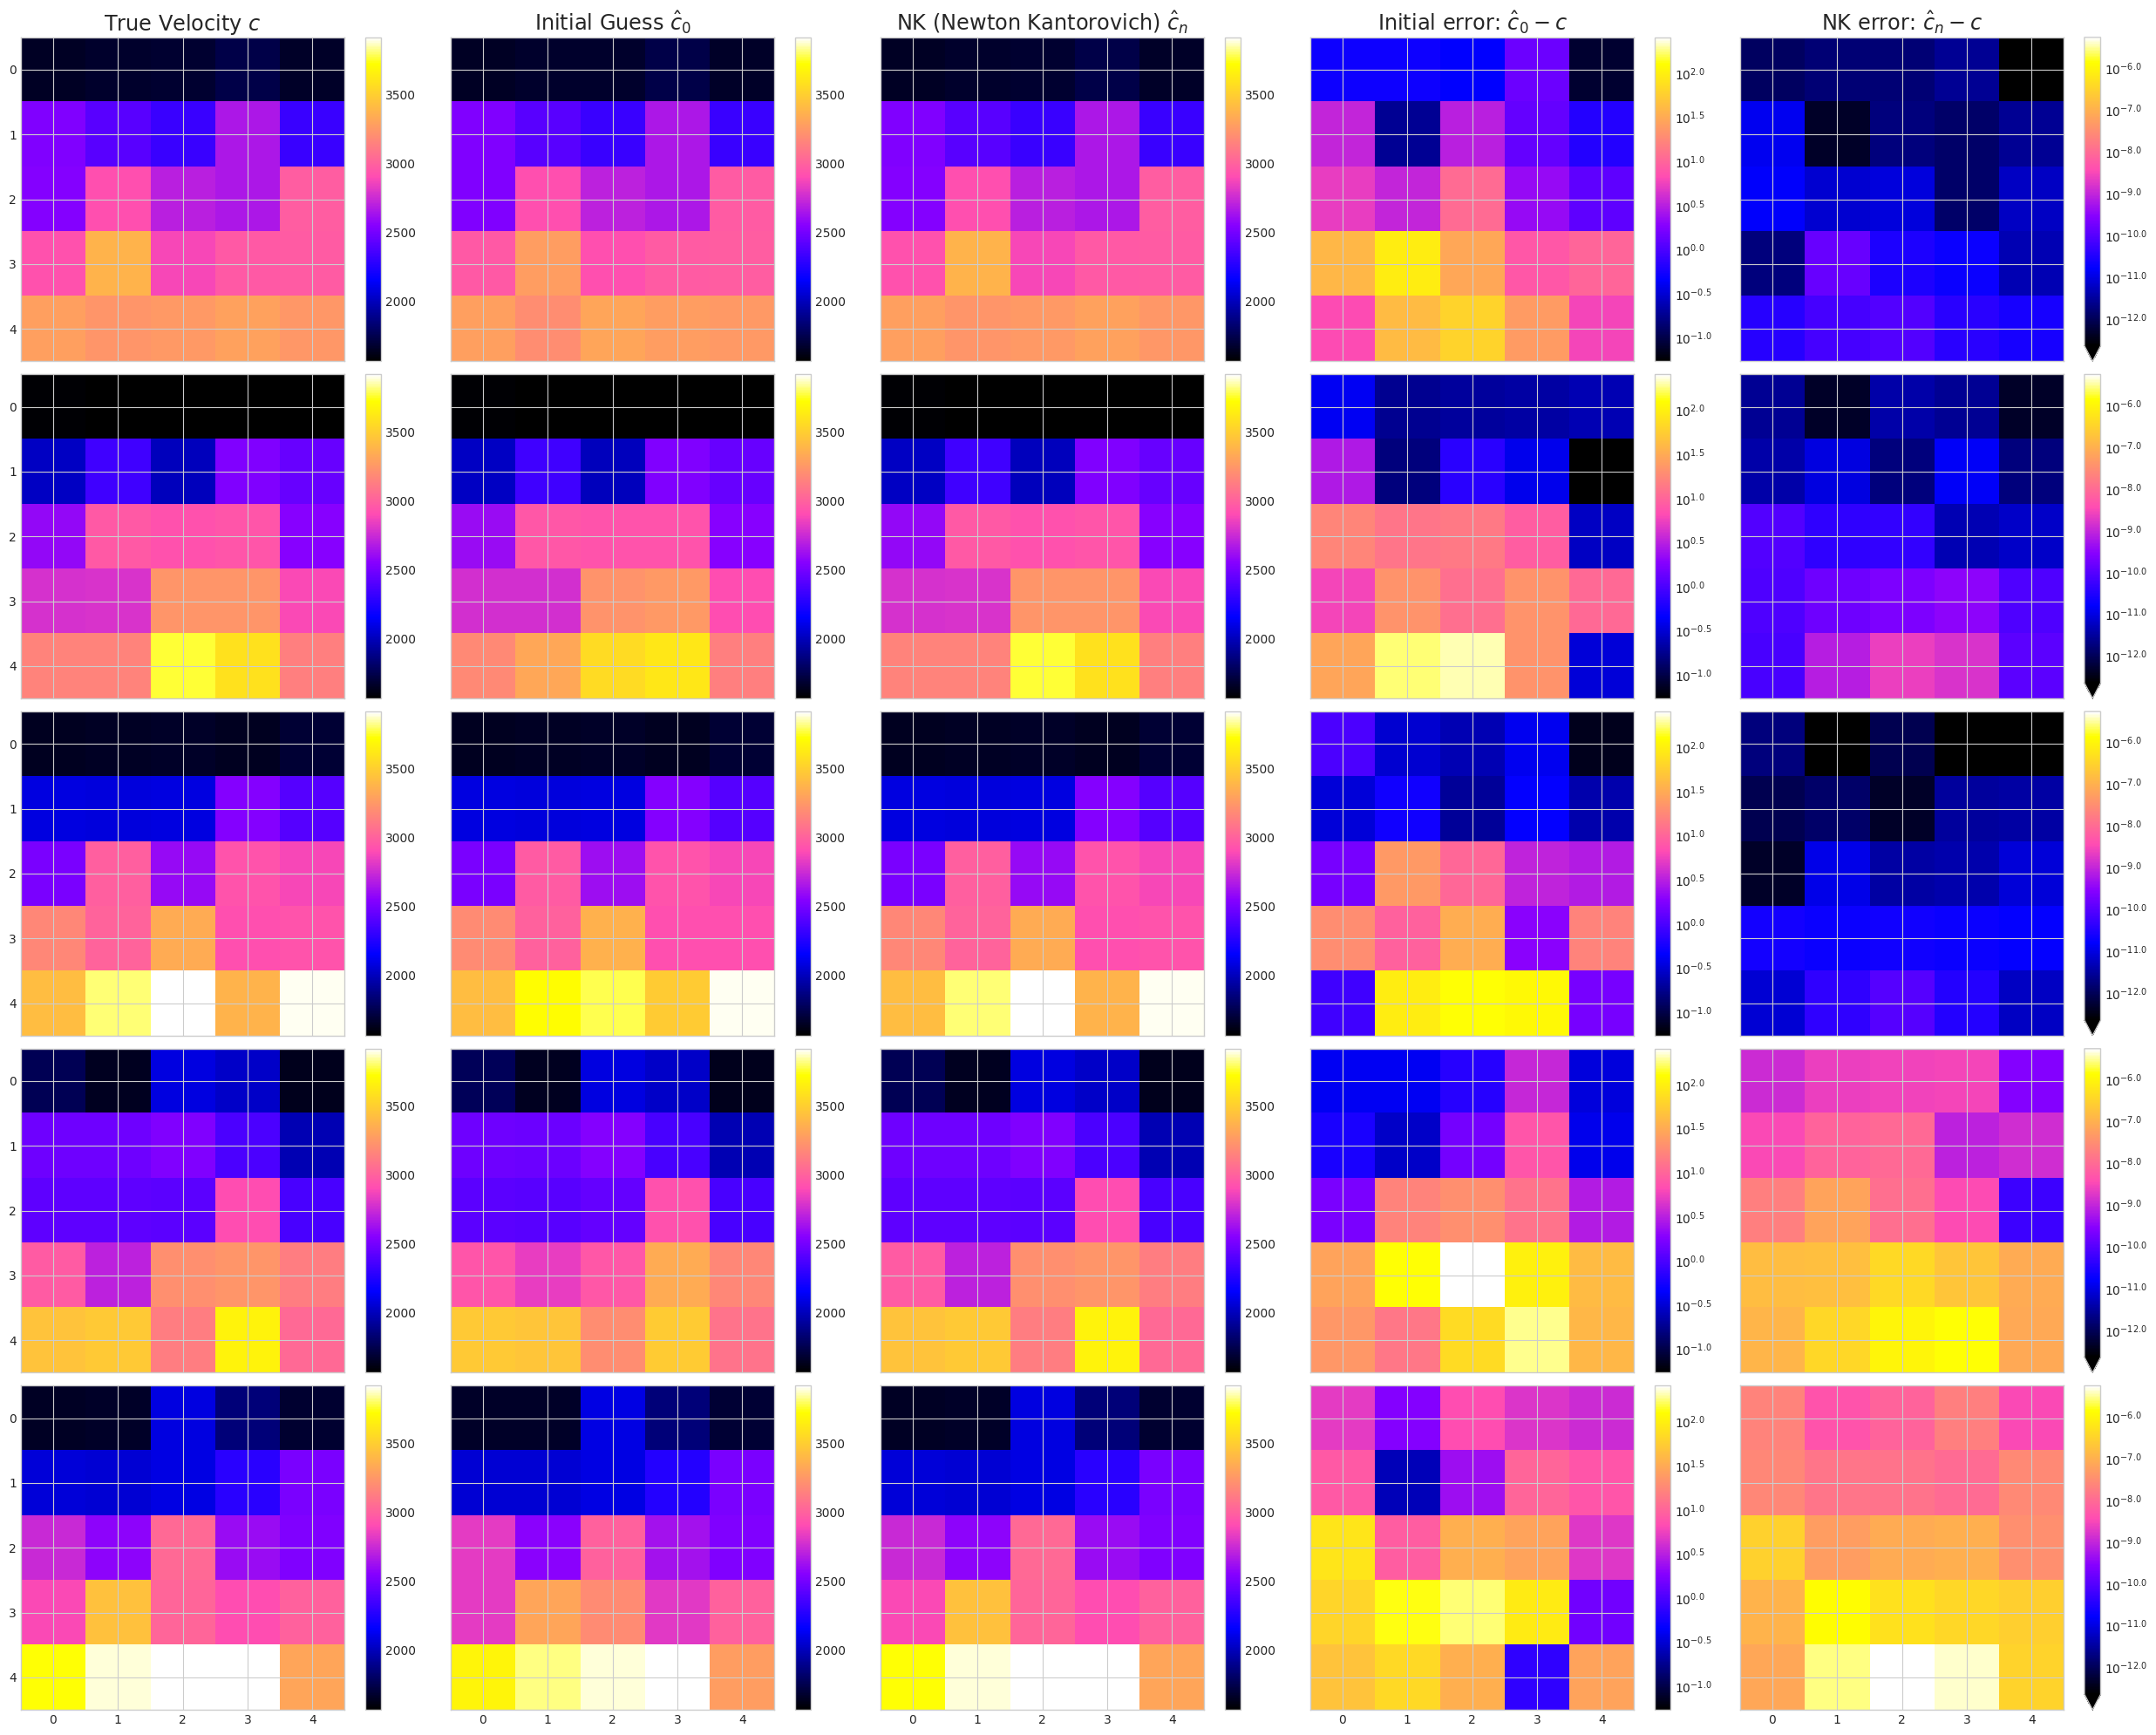

In [29]:
Rplt = 5
print(data_infer["l2rerrors"][:Rplt,0])
print(data_infer["l2rerrors"][:Rplt,-1])
plot_nk_velocities(vref.cpu()[:Rplt],data_infer["vs"][:Rplt,0].cpu(),data_infer["vs"][:Rplt,-1].cpu());

## Timing Comparisonm

In [30]:
N_times_comp = 8

In [31]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_ig = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ = gp_ig_predictor_cls.forward_eval(inputs_ig_cls.w_v[[i]])
        tend.record()
        torch.cuda.synchronize()
        times_ig[i] = t0.elapsed_time(tend)/1000
    print("times_ig")
    print(times_ig) 
    print("times_ig.median() = %.1e"%times_ig.median())

times_ig
tensor([0.3207, 0.0015, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012])
times_ig.median() = 1.2e-03


In [32]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris_model = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ = gp_predictor_cls.forward_eval(inputs_cls.inputs_v[[i]])
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris_model[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris_model")
    print(times_chonknoris_model) 
    print("times_chonknoris_model.median() = %.1e"%times_chonknoris_model.median())

times_chonknoris_model
tensor([0.7319, 0.0016, 0.0014, 0.0014, 0.0013, 0.0013, 0.0013, 0.0013])
times_chonknoris_model.median() = 1.3e-03


In [33]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        fwi_gn_solver(p,w[[i]],v0[[i]],Thetainv_v=Thetainv_v.to(DEVICE),Thetainv_w=Thetainv_w.to(DEVICE),vref=vref[[i]],
                             predict=InferenceMachine(gp_predictor_cls, inputs_cls).predict,
                             num_newton_iter=num_newton_iter,
                             relaxation=1e1,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,np.inf),
                             range_lrs = (0,np.inf),
                             print_rmse_flow=False,
                             verbose = verbose
                             )
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris")
    print(times_chonknoris) 
    print("times_chonknoris.median() = %.1e"%times_chonknoris.median())

    iter of 40     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 3.10e-01  | 5.31e-01     5.31e-01     5.31e-01     5.31e-01     100.0        | 1.01e-02     1.01e-02     1.01e-02     1.01e-02     | 1.00e+01     1.00e+01     1.00e+01     1.00e+01     | 1.00e+